Importing relevant libraries

In [1]:
import os
import random
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px

import math
from scipy import special #comb, factorial
#from keras import backend as K
from scipy.stats import uniform
from matplotlib import pyplot as plt
from sklearn import tree
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest,chi2
from sklearn.preprocessing import MinMaxScaler, StandardScaler,LabelEncoder

%matplotlib inline
# from sklearn.metrics import classification_report, roc_auc_score, recall_score, make_scorer, plot_confusion_matrix, confusion_matrix, accuracy_score,f1_score

In [2]:
sns.set_style('darkgrid')

In [3]:
df = pd.read_csv('Groceries_dataset.csv')
df.head()

,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk


In [12]:
df[df["Member_number"]==1808]

,Member_number,Date,itemDescription,year
0,1808,2015-07-21,tropical fruit,2015
4355,1808,2015-02-04,long life bakery product,2015
9090,1808,2014-11-29,meat,2014
11488,1808,2014-12-15,sugar,2014
16149,1808,2015-07-21,rolls/buns,2015
20504,1808,2015-02-04,semi-finished bread,2015
25239,1808,2014-11-29,whole milk,2014
27637,1808,2014-12-15,citrus fruit,2014
36088,1808,2015-07-21,candy,2015
38731,1808,2014-12-15,napkins,2014


Basic info about the dataset

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38765 entries, 0 to 38764
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Member_number    38765 non-null  int64         
 1   Date             38765 non-null  datetime64[ns]
 2   itemDescription  38765 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 908.7+ KB


Do we have nulls?

In [5]:
df.isnull().sum()

Member_number      0
Date               0
itemDescription    0
dtype: int64

No, we don't

In [6]:
df.shape

(38765, 3)

# How many unique shopping items do we have?

In [7]:
df['itemDescription'].unique().size

167

# When were the purchases made?

In [ ]:
print(sns.__version__)

In [8]:
df['Date'] = pd.to_datetime(df['Date'])

C:\Users\Dev\AppData\Local\Temp\ipykernel_37364\2394721818.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


In [10]:
df["year"] = df['Date'].apply(lambda x: x.year)
df["year"]

0        2015
1        2015
2        2015
3        2015
4        2015
         ... 
38760    2014
38761    2014
38762    2014
38763    2014
38764    2014
Name: year, Length: 38765, dtype: int64

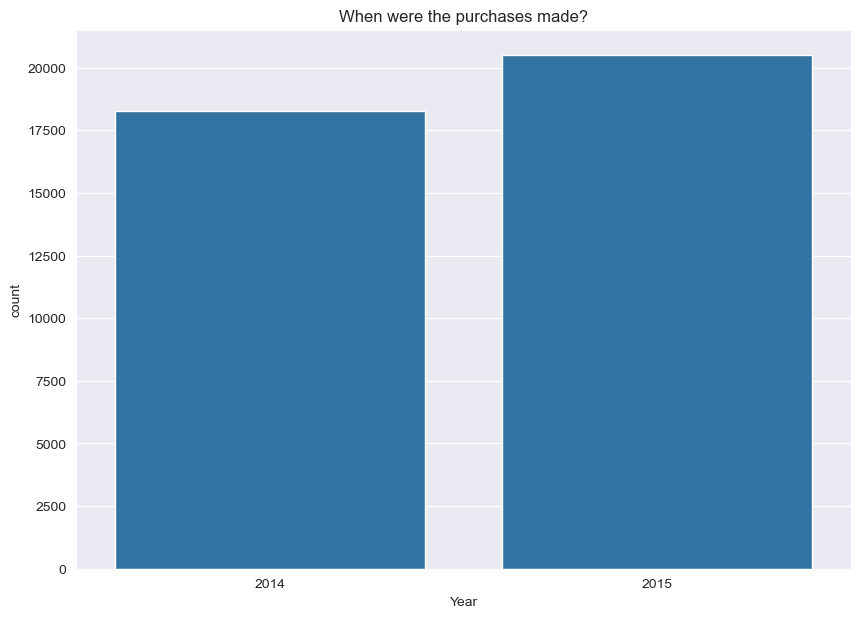

In [11]:
plt.figure(figsize=(10,7))
sns.countplot(data=df, x="year")
plt.title('When were the purchases made?')
plt.xlabel('Year')
plt.show()

We see that the dataset contains the purchases made only in 2014 and 2015. Now let's see more specific distribution

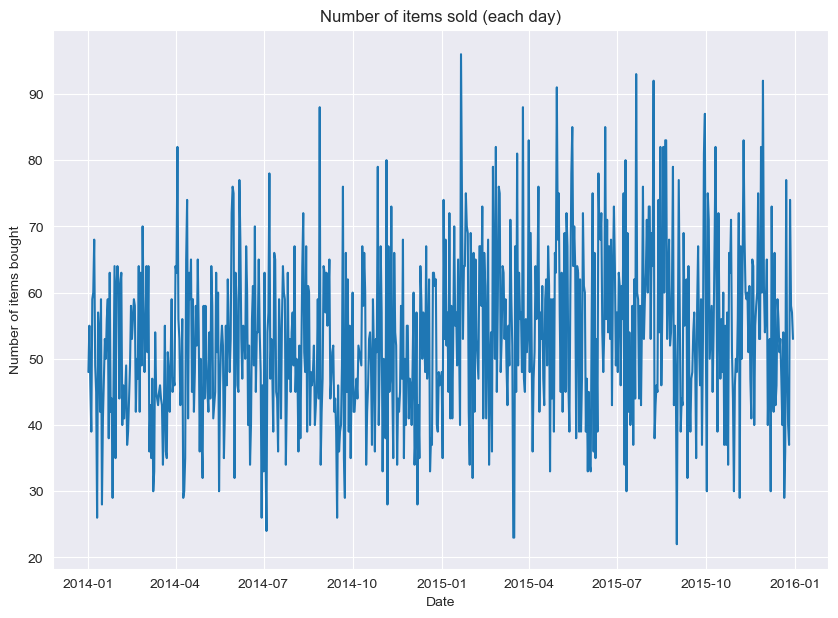

In [13]:
plt.figure(figsize=(10,7))
df3 = df.groupby('Date').count()['itemDescription'].reset_index()
plt.plot(df3['Date'],df3['itemDescription'])
plt.xlabel('Date')
plt.ylabel('Number of items bought')
plt.title('Number of items sold (each day)')
plt.show()

Let's reduce the noise by consider total count of items bougth **each month**.

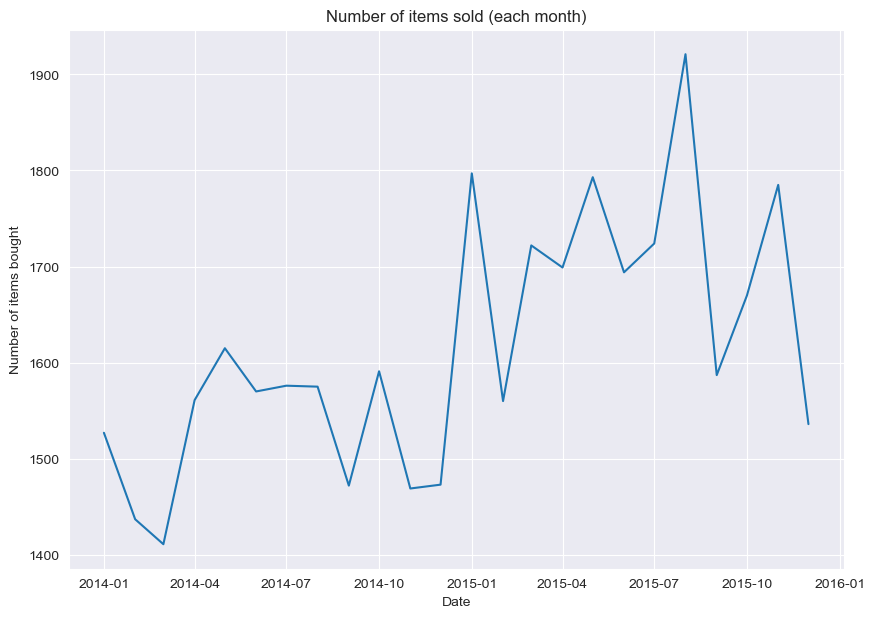

In [14]:
plt.figure(figsize=(10,7))
df3 = df.copy()
df3['Date'] = df3['Date'].apply(lambda x: pd.to_datetime(f"{x.year}/{x.month}/{1}"))
df3 = df3.groupby('Date').count()['itemDescription'].reset_index()

plt.plot(df3['Date'], df3['itemDescription'])
plt.xlabel('Date')
plt.ylabel('Number of items bought')
plt.title('Number of items sold (each month)')
plt.show()

To get a better idea of whether there is some yearly trend, we will adjust the graph as follows:

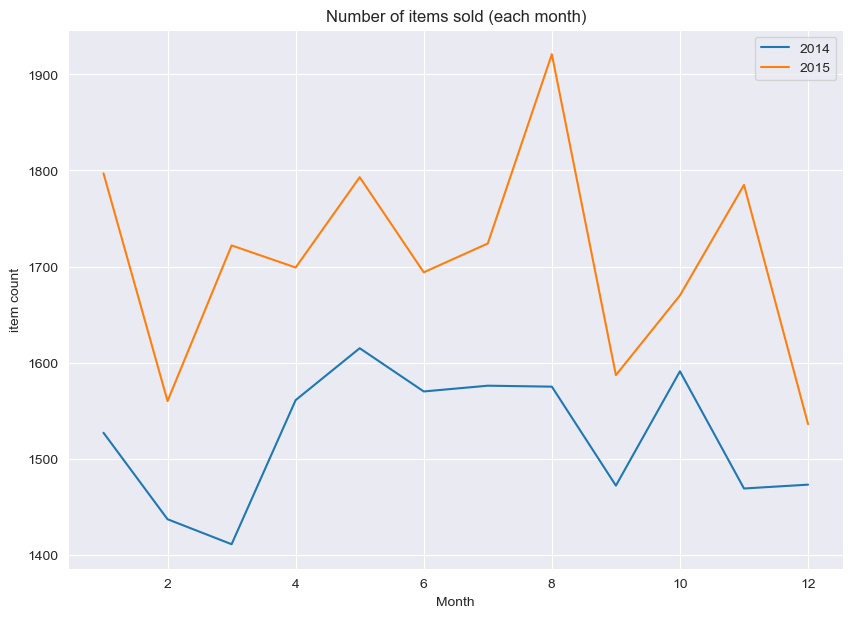

In [15]:
df3 = df.copy()
df3['Year'] = df['Date'].apply(lambda x: x.year)
df3['Month'] = df['Date'].apply(lambda x: x.month)
df3.drop(['Member_number','Date'],axis=1,inplace=True)
df3 = df3.groupby(['Year','Month']).count().reset_index()

d_2014 = df3[df3['Year'] == 2014]
d_2015 = df3[df3['Year'] == 2015]

plt.figure(figsize=(10,7))
plt.plot(d_2014['Month'],d_2014['itemDescription'],label='2014')
plt.plot(d_2015['Month'],d_2015['itemDescription'],label='2015')
plt.title('Number of items sold (each month)')
plt.xlabel('Month')
plt.ylabel('item count')
plt.legend()
plt.show()

In [16]:
corr=d_2014.merge(right=d_2015,on='Month')[['itemDescription_x','itemDescription_y']].corr().values[0][1]
print(f'Correlation between sales in 2014 and 2015: {corr}')

Correlation between sales in 2014 and 2015: 0.4654402963659504


Couple notes can be made here:
1. Besides February, sales in each month of 2015 were higher than in the same month of 2014.
2. There doesn't seem to be any yearly trend: correlation between the sales in 2014 and 2015 is roughly 1%.

Now let's look at the sales per each item

In [17]:
df1 = df.groupby('itemDescription').count().sort_values(by='Member_number',ascending=False).reset_index()
df1.rename(columns={'itemDescription': 'Item',
                   'Member_number': 'Number of sales'},inplace=True)
df1.drop(['Date','year'],axis=1,inplace=True)
df1

,Item,Number of sales
0,whole milk,2502
1,other vegetables,1898
2,rolls/buns,1716
3,soda,1514
4,yogurt,1334
...,...,...
162,rubbing alcohol,5
163,bags,4
164,baby cosmetics,3
165,preservation products,1


Summary of the `Number of sales`

In [18]:
df1['Number of sales'].describe()

count     167.000000
mean      232.125749
std       363.442098
min         1.000000
25%        30.500000
50%        85.000000
75%       264.000000
max      2502.000000
Name: Number of sales, dtype: float64

Let's look at the histogram plotting the distribution of the `Number of sales`

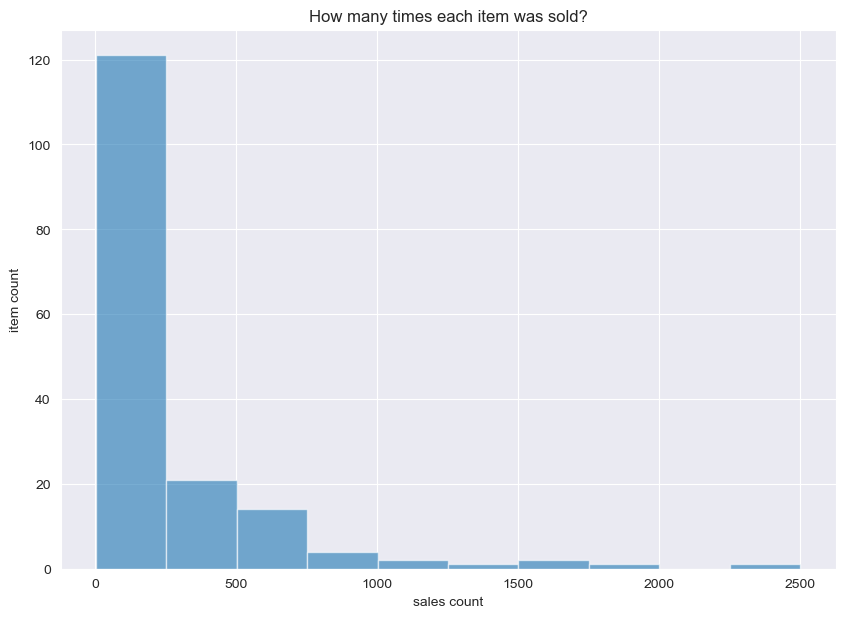

In [19]:
plt.figure(figsize=(10,7))
df1['Number of sales'].hist(alpha=0.6)
plt.xlabel('sales count')
plt.ylabel('item count')
plt.title("How many times each item was sold?")
plt.show()

We see that half of the items were purchased less than $86$ times. However, there are some outliers. Let's have a look at what the outliers are.

In [21]:
df1 = df.groupby('itemDescription').count().sort_values(by='Member_number',ascending=False).head(10).reset_index()
df1.drop(['Date'],axis=1,inplace=True)
df1.rename(columns={'itemDescription': 'Item',
                   'Member_number' : 'Number of sales'},inplace=True)

import plotly.express as px
fig = px.bar(df1,
             x='Item',
             y='Number of sales',
             title= 'Most purchased items')
fig.show()

Now let's have a look at the customers that bought the most items.

In [22]:
df1 = df.groupby('Member_number').count().sort_values(by='itemDescription',ascending=False).head(10).reset_index()
df1.drop(['Date'],axis=1,inplace=True)
df1.rename(columns={'itemDescription': 'Item count',
                   'Member_number' : 'Customer ID'},inplace=True)
df1['Customer ID'] = df1['Customer ID'].astype(str)
df1.head()

,Customer ID,Item count,year
0,3180,36,36
1,3737,33,33
2,3050,33,33
3,2051,33,33
4,3915,31,31


In [23]:
fig = px.bar(df1,
             x='Customer ID',
             y='Item count',
             title='Customers that purchased the most items')
fig.show()

As things stand, our data is organized in a way that we can not determine how many items (and what items exactly) each customer bought PER EACH VISIT to the store. For example, have a look at the following table

In [24]:
df[df['Member_number'] == 1000].sort_values(by='Date').head(3)

,Member_number,Date,itemDescription,year
13331,1000,2014-06-24,whole milk,2014
29480,1000,2014-06-24,pastry,2014
32851,1000,2014-06-24,salty snack,2014


We see that the customer with an ID 1000 bought 3 items on July 4, 2014. The problem is though, we don't know how many times he went to the store, and what he bought per each visit. For example, it is possible that he went to the store 3 times, each time buying single item. It is also possible that he went to the store 2 times, the first time he bought pastry and snack, and the second time he bought milk. Or maybe he went to the store only once, and bought all 3 items at once. Which one is it? We don't know. But to perform any meaningful association analysis, we need to know. Since no information was provided, we will make the following assumption:

> **Assumption**. On each day, arbitrary customer went to the store ONLY ONCE.


With this assumption in mind, we can reorganize the dataset in a following way:


In [25]:
df1 = df.copy()
df1['itemDescription'] = df1['itemDescription'].apply(lambda x: [x,]).copy()
df1 = df1.groupby(['Member_number','Date']).agg(sum).reset_index()
df1.rename(columns={'itemDescription': 'Items bought'},inplace=True)
df1.head()

,Member_number,Date,Items bought,year
0,1000,2014-06-24,"[whole milk, pastry, salty snack]",6042
1,1000,2015-03-15,"[sausage, whole milk, semi-finished bread, yog...",8060
2,1000,2015-05-27,"[soda, pickled vegetables]",4030
3,1000,2015-07-24,"[canned beer, misc. beverages]",4030
4,1000,2015-11-25,"[sausage, hygiene articles]",4030


`Items bought` now represents the set of all items which were bought during a single visit to the store.

Let's see how many items customers purchase per each visit to the store.

In [26]:
df1['Basket size'] = df1['Items bought'].apply(lambda x: len(x))

In [27]:
df1['Basket size'].describe()

count    14963.000000
mean         2.590724
std          1.117469
min          2.000000
25%          2.000000
50%          2.000000
75%          3.000000
max         11.000000
Name: Basket size, dtype: float64

In [31]:
df1.shape

(14963, 5)

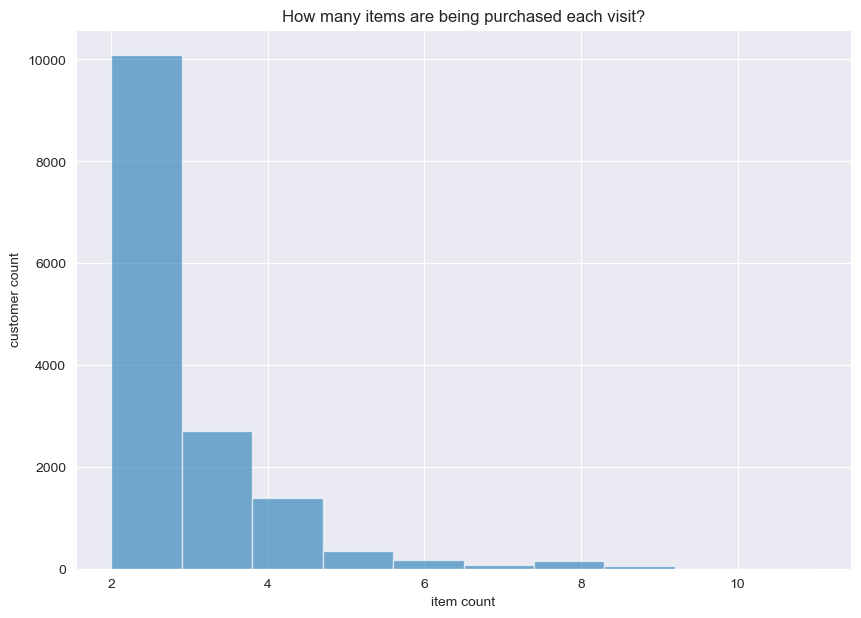

In [30]:
plt.figure(figsize=(10,7))
df1['Basket size'].hist(alpha=0.6)
plt.xlabel('item count')
plt.ylabel('customer count')
plt.title("How many items are being purchased each visit?")
plt.show()

We see that most customers purchase 2 items per each visit to the store.

Now we will use [Association rule learning](https://en.wikipedia.org/wiki/Association_rule_learning) to check whether there are some patterns in the customers purchasing behavior. To generate set of relevant rules, we will use [Apriori algorithm](https://en.wikipedia.org/wiki/Apriori_algorithm). Before proceeding, make sure that you are fimiliar with following concepts: association rule, support, confidence, lift (information regarding all of these concepts can be found in the [here](https://en.wikipedia.org/wiki/Association_rule_learning) (see section "Useful Concepts")).


We will only generate rules where support exceeds $0.1\%$ and confidence exceeds $10\%$
    

In [32]:
import mlxtend as ml
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

In [33]:
df1 = df.copy()
df1['itemDescription'] = df1['itemDescription'].apply(lambda x: [x,]).copy()
df1 = df1.groupby(['Member_number','Date']).agg(sum).reset_index()
df1.rename(columns={'itemDescription': 'Items bought'},inplace=True)
df1.head()

,Member_number,Date,Items bought,year
0,1000,2014-06-24,"[whole milk, pastry, salty snack]",6042
1,1000,2015-03-15,"[sausage, whole milk, semi-finished bread, yog...",8060
2,1000,2015-05-27,"[soda, pickled vegetables]",4030
3,1000,2015-07-24,"[canned beer, misc. beverages]",4030
4,1000,2015-11-25,"[sausage, hygiene articles]",4030


In [34]:
all_items = df['itemDescription'].unique()
data = []

for transaction in df1['Items bought']:
    row = []
    for item in all_items:
        if item in transaction:
            row.append(1)
        else:
            row.append(0)
    data.append(row)

df2 = pd.DataFrame(data,columns=all_items)    
df2 = df2.rename_axis('Transcation ID')
df2.head()

,tropical fruit,whole milk,pip fruit,other vegetables,rolls/buns,pot plants,citrus fruit,beef,frankfurter,chicken,...,flower (seeds),rice,tea,salad dressing,specialty vegetables,pudding powder,ready soups,make up remover,toilet cleaner,preservation products
Transcation ID,,,,,,,,,,,,,,,,,,,,,
0,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [36]:
df2.shape

(14963, 167)

In [37]:
frequent_itemsets = apriori(df2, min_support=0.001, use_colnames=True)
frequent_itemsets

C:\Users\Dev\anaconda3\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:109: DeprecationWarning:

DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type



,support,itemsets
0,0.067767,(tropical fruit)
1,0.157923,(whole milk)
2,0.049054,(pip fruit)
3,0.122101,(other vegetables)
4,0.110005,(rolls/buns)
...,...,...
745,0.001136,"(rolls/buns, whole milk, sausage)"
746,0.001002,"(whole milk, soda, rolls/buns)"
747,0.001470,"(yogurt, whole milk, sausage)"
748,0.001069,"(whole milk, soda, sausage)"


In [38]:
rules = association_rules(frequent_itemsets, metric="lift")
rules.sort_values('confidence', ascending = False, inplace = True)

In [39]:
rules = rules[rules['confidence'] > 0.1].copy()
rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
717,"(yogurt, sausage)",(whole milk),0.005748,0.157923,0.001470,0.255814,1.619866,0.000563,1.131541,0.384877
711,"(sausage, rolls/buns)",(whole milk),0.005347,0.157923,0.001136,0.212500,1.345594,0.000292,1.069304,0.258214
724,"(soda, sausage)",(whole milk),0.005948,0.157923,0.001069,0.179775,1.138374,0.000130,1.026642,0.122281
124,(semi-finished bread),(whole milk),0.009490,0.157923,0.001671,0.176056,1.114825,0.000172,1.022008,0.103985
705,"(yogurt, rolls/buns)",(whole milk),0.007819,0.157923,0.001337,0.170940,1.082428,0.000102,1.015701,0.076751


Let's see how many assofication rules we are dealing with:

In [40]:
rows = rules.shape[0]
print(f'Number of rules: {rows}')

Number of rules: 99


Sstatistics summary regarding `support`:

In [41]:
rules['support'].describe()

count    99.000000
mean      0.002737
std       0.002233
min       0.001002
25%       0.001337
50%       0.001804
75%       0.003342
max       0.013968
Name: support, dtype: float64

We see that the support for all rules in our dataset is very low (i.e., the proportion of transactions that involve items from both baskets), which may be problematic, due to the fact that any results obtained from analysis may not be statistically significant.

Let's see the rules with the highest lift

In [42]:
rules.sort_values(by='lift',ascending=False).head(10).iloc[:,:-2][['antecedents',
                                                                  'consequents',
                                                                   'consequent support',
                                                                  'lift']]

,antecedents,consequents,consequent support,lift
716,"(whole milk, yogurt)",(sausage),0.060349,2.182917
718,"(whole milk, sausage)",(yogurt),0.085879,1.911760
717,"(yogurt, sausage)",(whole milk),0.157923,1.619866
20,(flour),(tropical fruit),0.067767,1.617141
560,(processed cheese),(root vegetables),0.069572,1.513019
493,(soft cheese),(yogurt),0.085879,1.474952
471,(detergent),(yogurt),0.085879,1.444261
488,(chewing gum),(yogurt),0.085879,1.358508
711,"(sausage, rolls/buns)",(whole milk),0.157923,1.345594
248,(processed cheese),(rolls/buns),0.110005,1.315734


We see that itemsets (yogurt, whole milk) and (sausage) have the highest lift. That means that once we know that a customer has bought yogurt and whole milk, it becomes 2.2 times more likely that he will also buy sausage. But as we've pointed out, due to the fact that the support is very low, we cannot really determine whether this is just a fluke or a real association.

Similarly, we will check the the rules with the lower lift (i.e., rules where the items in antecedent and consequent are unlikely to be bought together).

In [43]:
rules.sort_values(by='lift',ascending=True).head(10).iloc[:,:-2][['antecedents',
                                                                  'consequents',
                                                                   'consequent support',
                                                                  'lift']]

,antecedents,consequents,consequent support,lift
108,(margarine),(whole milk),0.157923,0.801379
121,(hygiene articles),(whole milk),0.157923,0.803109
55,(rolls/buns),(whole milk),0.157923,0.804028
100,(hard cheese),(whole milk),0.157923,0.805917
98,(ice cream),(whole milk),0.157923,0.808960
76,(canned beer),(whole milk),0.157923,0.811821
56,(pot plants),(whole milk),0.157923,0.811821
67,(fruit/vegetable juice),(whole milk),0.157923,0.821072
68,(yogurt),(whole milk),0.157923,0.822940
113,(oil),(whole milk),0.157923,0.823471


Let's visualize the relation between support, confidence and lift

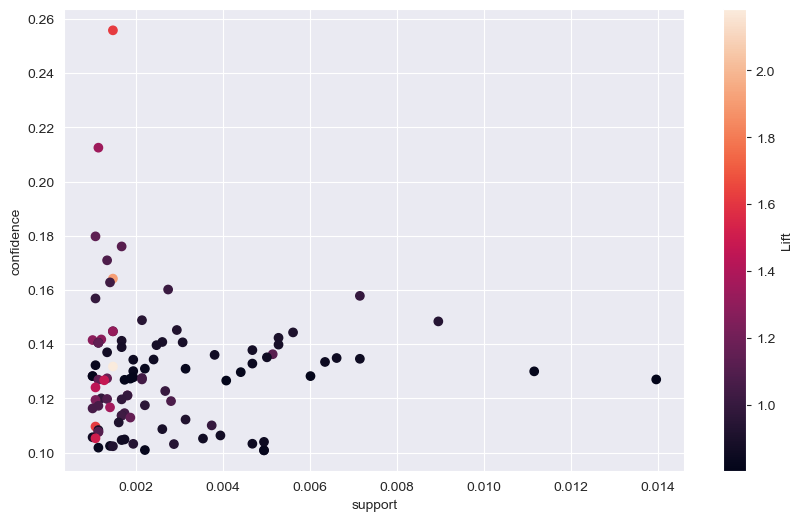

In [44]:
sup = rules['support'].values
conf = rules['confidence'].values
lift = rules['lift'].values

plt.figure(figsize=(10,6))
sc = plt.scatter(sup,conf,c=lift)
plt.colorbar(sc,label='Lift')
plt.xlabel('support')
plt.ylabel('confidence')
plt.show()

As we see, most rules have both low confidence and low support. However, there is one rule that we may want to single out: the rule with the confidence of about $26\%$:

In [45]:
rules[rules['confidence'] > 0.24]

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
717,"(yogurt, sausage)",(whole milk),0.005748,0.157923,0.00147,0.255814,1.619866,0.000563,1.131541,0.384877


We see that the probability of a customer buying milk is roughly $16\%$. But given that the customer has bougth yougurt and sausage, the probability of buying milk increases to $25\%$ (this also signifies that the rule has a high lift). But again, support is very low (only $0.1\%$). So while this rule seems to be the most promising out  of rules our dataset contains, due to the fact that the support is very low, one should not make any rash conclusions about the association between the two itemsets without further investigation. How could one investigate? One  option is to come up with a way to directly (or indirectly) ask those customers who bought yogurt, sausage and whole milk about why they buy these items together.

Based on the graph above, one could also see some rules with a relatively decent support (i.e., support exceeds $1\%$), let's check what those rules are:

In [ ]:
rules[rules['support'] > 0.01]

Not only confidence is low for both of these rules, but the lift is actually less than 1. For example, the probability of a customer buying whole milk is about $16\%$. But if we know that the customer bought yogurt, then the probability of buying whole milk drops to $13\%$. The upshot is: these rules are not of much interest to us.

### Conclusions:

1. The dataset contains transactions made in 2014 and 2015.
2. In each month of 2015 (besides February), the sales (i.e, total count of items sold) grew from a year earlier. Furthermore, the correlation between the sales of 2014 and 2015 is low (around 1%), which implies there is no yearly sales trend.
3. The dataset contains 167 unique shopping items.
4. Over the span of two years, half of the shopping items were bought less than 85 items each. The most popular items (i.e, those items that were bought more than 1k times) are:

    - whole milk (bought 2502 times)
    - other vegetables (bought 1898 times)
    - rolls/buns (bought 1716 times)
    - soda (bought 1514 times)
    - yogurt (bought 1334 times)
    - root vegetables (bought 1071 times)
    - tropical fruit (bought 1032 times)
5. Per each visit to the store, half of the customers only purchases 2 items (or less), and 95% of the customers purchase 5 items (or less).

6. Using Apriori algorithm (AA), we've found that most rules have very low support (which implies that even if one finds one rule to have a strong association, the association might not be statistically significant). Furthermore, using AA we've found that most rules have low confidence and low lift (which signifies a weak association). The only rule which may have a meanignful association is $$\text{(yogurt, sausage)} \implies \text{(whole milk)}$$
the reason why the rule may be meaningful is because of the highest confidence out of all rules ($\approx 26\%$), and one of the highest lifts ($\approx 1.6$). This means that, once we know the customer has purchased yogurt and sausage, the probability of the customer also buying whole milk significantly increases. However, given that the support is low ($\approx 0.1\%$), one should be careful before making any conclusions about whether the association is significant.

## Apriori Algorithm

* Now time to apply algorithm on data.
* We have to provide `min_support`, `min_confidence`, `min_lift`, and `min length` of sample-set for find rule.

#### Measure 1: Support.
This says how popular an itemset is, as measured by the proportion of transactions in which an itemset appears. In Table 1 below, the support of {apple} is 4 out of 8, or 50%. Itemsets can also contain multiple items. For instance, the support of {apple, beer, rice} is 2 out of 8, or 25%.

![](https://annalyzin.files.wordpress.com/2016/04/association-rule-support-table.png?w=503&h=447)

If you discover that sales of items beyond a certain proportion tend to have a significant impact on your profits, you might consider using that proportion as your support threshold. You may then identify itemsets with support values above this threshold as significant itemsets.

#### Measure 2: Confidence. 
This says how likely item Y is purchased when item X is purchased, expressed as {X -> Y}. This is measured by the proportion of transactions with item X, in which item Y also appears. In Table 1, the confidence of {apple -> beer} is 3 out of 4, or 75%.

![](https://annalyzin.files.wordpress.com/2016/03/association-rule-confidence-eqn.png?w=527&h=77)

One drawback of the confidence measure is that it might misrepresent the importance of an association. This is because it only accounts for how popular apples are, but not beers. If beers are also very popular in general, there will be a higher chance that a transaction containing apples will also contain beers, thus inflating the confidence measure. To account for the base popularity of both constituent items, we use a third measure called lift.

#### Measure 3: Lift. 
This says how likely item Y is purchased when item X is purchased, while controlling for how popular item Y is. In Table 1, the lift of {apple -> beer} is 1,which implies no association between items. A lift value greater than 1 means that item Y is likely to be bought if item X is bought, while a value less than 1 means that item Y is unlikely to be bought if item X is bought.
![](https://annalyzin.files.wordpress.com/2016/03/association-rule-lift-eqn.png?w=566&h=80)